# Perbandingan antara Skip-Gram dan TF-IDF pada 200 Berita

Data yang dipakai adalah `detik_berita.csv`, hasil crawl website detik yang
terdiri dari 200 berita: 100 bertema finance dan 100 bertema olahraga.

Alur kerja pada notebook ini berurutan sebagai berikut. Pertama, teks berita
dimasukkan ke tahap preprocessing. Kedua, data yang sudah bersih itu dipecah
80% untuk training dan 20% untuk testing. Ketiga, teks bagian training diubah
menjadi vektor. Keempat, vektor berita dikirim ke Gaussian Naive Bayes dan
diuji pada bagian 20%.

Teks dipecah jadi kata dengan dua jalur preprocessing, dan kedua jalur dipakai
apa adanya oleh semua teknik vektorisasi di notebook ini:

- **Jalur A - tanpa preprocessing**: teks berita dipakai apa adanya, hanya
  case folding lalu dipecah jadi kata. Emoji, tanda baca, bahasa tidak baku,
  dan kata umum semuanya dibiarkan.
- **Jalur B - dengan preprocessing**: teks berita sudah dibersihkan lebih dulu,
  baru dipecah jadi kata.

Vektorisasi teks sendiri dijalankan dua kali, supaya keduanya bisa dibandingkan
pada klasifikasi yang sama:

- **Skip-Gram**: Word2Vec `sg=1` dilatih 50 epoch hanya di 160 berita training.
  Vektor berita diambil sebagai rata-rata semua vektor kata di dalamnya.
- **TF-IDF**: `TfidfVectorizer` di-`fit` pada 160 berita training yang sama.
  Vektor berita diambil langsung dari baris matriks TF-IDF.

Section pertama membahas Skip-Gram, mulai dari statistik vocabulary, tabel
vektor kata, klasifikasi, sampai diagram batang. Section kedua mengulang alur
yang sama persis dengan TF-IDF, lalu menutup notebook dengan perbandingan
langsung antara kedua teknik.

Pada kedua section, **hanya teknik vektorisasi yang berubah**. Data, pembagian
80/20, jalur A dan B, algoritma Gaussian Naive Bayes, dan metrik evaluasinya
dikunci sama persis, supaya selisih hasil benar-benar bisa dikaitkan ke teknik
vektorisasi saja.

## Import Library

Library yang dibutuhkan: `re` dan `string` untuk membersihkan teks, `time` untuk
mengukur durasi pelatihan, `numpy` dan `pandas` untuk menangani data dan vektor,
`gensim` untuk melatih Word2Vec skip-gram, `sklearn` untuk pembagian data dan
Gaussian Naive Bayes beserta metrik evaluasinya, lalu `matplotlib` untuk
menggrafik hasil perbandingan.

In [1]:
import re
import string
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")
print(f"gensim  {Word2Vec.__module__.split('.')[0]} siap")
print("sklearn train_test_split + GaussianNB siap")

pandas  3.0.5
numpy   2.5.3
gensim  gensim siap
sklearn train_test_split + GaussianNB siap


## Load Data

Data dibaca dari `detik_berita.csv` yang dipisah dengan titik koma. Kolom `id`
dan `isi_berita` dibersihkan dari spasi berlebih, berita kosong diganti string
kosong supaya tidak error saat diproses. Setelah itu dicek jumlah berita,
sebaran tiap tema, dan rata-rata panjang berita.

Dua hal yang perlu diperhatikan: jumlah berita harus genap 200, dan tiap tema
harus sama besar. Kalau tidak sama, nilai accuracy bisa condong ke kelas yang
lebih banyak.

In [2]:
df = pd.read_csv("detik_berita.csv", sep=";", dtype=str)
df.columns = [c.strip() for c in df.columns]
df["id"] = df["id"].str.strip()
df["isi_berita"] = df["isi_berita"].fillna("")

print(f"{len(df)} berita | kolom: {list(df.columns)}")
print(df["tema"].value_counts().to_string())
print(f"\nRata-rata panjang berita: {df['isi_berita'].str.len().mean():.0f} karakter")
df.head()

200 berita | kolom: ['id', 'isi_berita', 'tema']
tema
finance     100
olahraga    100

Rata-rata panjang berita: 2218 karakter


,id,isi_berita,tema
0,1,Harga emas Antam terus mengalami penurunan dan...,finance
1,2,"Perdana Menteri (PM) Singapura, Lawrence Wong,...",finance
2,3,Semua masyarakat akan memiliki rekening bank. ...,finance
3,4,"CEO Badan Pengelola Investasi (BPI) Danantara,...",finance
4,5,Jakarta - Kampoeng Mainan di Blok M Square men...,finance


## Preprocessing

Preprocessing mengikuti urutan pipeline dari Tugas 2. Urutannya penting, karena
tiap tahap menghasilkan teks yang jadi bahan tahap berikutnya.

1. **Case folding** - seluruh huruf diubah menjadi huruf kecil, supaya
   `Saham` dan `saham` dianggap kata yang sama.
2. **Hapus emoji** - simbol emosi dan simbol lain yang tidak punya arti kata,
   misalnya Relacion ship. Regex-nya mencakup blok emoji unicode, simbol,
   variation selector, dan flag negara.
3. **Perbaiki bahasa tidak baku** - kata seperti `nggak`, `bikin`, `udah`
   diganti ke bentuk bakunya dengan `tidak`, `membuat`, `sudah`. Kata yang
   bentuk bakunya kosong, seperti `sih` dan `kok`, langsung dihapus. Kata
   diganti di tempatnya pakai `re.sub`, bukan dirakit ulang dari daftar kata,
   supaya posisinya dalam kalimat tetap terjaga.
4. **Hapus tanda baca** - titik, koma, tanda hubung, kurung, dan tanda baca
   lain diganti spasi. Kalau hanya dihapus tanpa diganti spasi, dua kata yang
   dipisah tanda baca seperti `Antam,turun` akan menyatu jadi `antamturun`.
5. **Tokenisasi** - teks bersih dipecah jadi daftar kata. Sekalian tahap ini
   membuang kata satu huruf dan kata asing yang tidak relevan.
6. **Hapus stopword** - kata umum seperti `yang`, `dan`, `di` dibuang, karena
   kata ini muncul di semua berita dan tidak membedakan antar tema.

Dua fungsi dibuat. `tokenisasi_b` menjalankan seluruh pipeline di atas.
`tokenisasi_a` hanya case folding lalu tokenisasi, tanpa langkah 2 sampai 6,
supaya ada pasangan pembanding yang benar-benar tanpa preprocessing.

In [3]:
KAMUS_TIDAK_BAKU = {
    "nggak": "tidak", "enggak": "tidak", "gak": "tidak", "kagak": "tidak",
    "udah": "sudah", "gitu": "begitu", "gini": "begini",
    "bikin": "membuat", "biarin": "biarkan", "cuma": "hanya",
    "aja": "saja", "tuh": "itu", "kayaknya": "sepertinya", "kayak": "seperti",
    "ngaco": "kacau", "banget": "sangat", "makin": "semakin",
    "dibilang": "dikatakan", "bilang": "berkata",
    "cuan": "untung", "karir": "karier",
    "ojol": "ojek", "detikers": "pembaca", "gede": "besar",
    "emang": "memang", "gimana": "bagaimana", "pakai": "memakai",
    "kalo": "kalau", "mesti": "harus", "dipindahin": "dipindahkan",
    "yg": "yang", "dgn": "dengan", "utk": "untuk", "spt": "seperti", "krn": "karena",
    "perkeonomian": "perekonomian", "pemeritah": "pemerintah", "menyetujul": "menyetujui",
    "sih": "", "kok": "", "deh": "", "dong": "", "lah": "", "toh": "", "loh": "", "mah": "",
    "kan": "", "nih": "",
}

KAMUS_ASING_SUBSTITUSI = {
    "import": "impor", "point": "poin", "tennis": "tenis",
    "elite": "elit", "standard": "standar",
}

KATA_ASING = {
    "a", "an", "and", "are", "as", "at", "be", "been", "but", "by", "can", "could",
    "do", "does", "did", "for", "from", "had", "has", "have", "he", "her", "his",
    "if", "in", "into", "is", "it", "its", "may", "might", "must", "not", "of", "on",
    "or", "she", "should", "so", "than", "that", "the", "their", "them", "there",
    "these", "they", "this", "those", "to", "was", "we", "were", "what", "when",
    "where", "which", "while", "who", "whom", "why", "will", "with", "would", "you",
    "your", "all", "any", "both", "each", "few", "more", "most", "other", "some",
    "such", "no", "own", "same", "too", "only", "just", "because", "until", "now",
    "very", "about", "after", "before", "between", "over", "under", "again", "further",
    "then", "once", "here", "men", "him", "us", "com", "www",
    "games", "champions", "league", "world", "race", "run", "set", "team", "start",
    "beach", "sport", "sports", "event", "fc", "super", "top", "pre", "center",
    "international", "approved", "online", "offline", "business", "price", "pricing",
    "market", "marketplace", "asset", "leveraging", "buy", "buyback", "corporate",
    "group", "location", "single", "streamlining", "commerce", "national", "investment",
    "artificial", "intelligence", "existing", "cost", "training", "tax", "village",
    "fame", "harmony", "marketing", "host", "buying", "panic", "tower", "fraud",
    "mission", "sprint", "tour", "time", "step", "running", "runner", "fun",
}

STOPWORDS_ID = {
    "yang", "dan", "di", "ke", "dari", "pada", "itu", "ini", "juga", "untuk",
    "dengan", "akan", "adalah", "ialah", "oleh", "karena", "agar", "sebagai",
    "para", "dalam", "serta", "atau", "masih", "sudah", "belum", "tidak",
    "bukan", "bisa", "dapat", "lebih", "saat", "ketika", "setelah", "sebelum",
    "selama", "melalui", "antara", "hingga", "kemudian", "lantas", "merupakan",
    "namun", "tetapi", "tapi", "terdapat", "ada", "adanya", "yaitu", "yakni",
    "terkait", "misalnya", "maupun", "seperti", "jika", "kalau", "maka", "harus",
    "hendak", "sangat", "paling", "semua", "setiap", "beberapa", "saya", "anda",
    "kami", "kita", "mereka", "dia", "ia", "kepada", "bagi", "pun",
    "saja", "mungkin", "lagi", "tersebut", "adapun", "beserta",
}

RE_EMOJI = re.compile(
    "[\U0001F000-\U0001FAFF\U00002600-\U000027BF\U0000FE00-\U0000FE0F"
    "\U0001F1E6-\U0001F1FF\U00002B00-\U00002BFF]+"
)

TANDA_BACA = string.punctuation + "«»“”‘’–—…"
RE_TANDA_BACA = re.compile(f"[{re.escape(TANDA_BACA)}]")
RE_KATA = re.compile(r"[a-z\u00e0-\u00ff]+")


def _normalisasi_kata(m):
    w = m.group()
    if len(w) < 2 or w in KATA_ASING:
        return " "
    return KAMUS_ASING_SUBSTITUSI.get(w, KAMUS_TIDAK_BAKU.get(w, w))


def tokenisasi_a(teks):
    # case folding saja, lalu dipecah jadi kata
    return RE_KATA.findall(teks.casefold())


def tokenisasi_b(teks):
    # case folding -> hapus emoji -> bahasa tidak baku -> hapus tanda baca
    # -> tokenisasi -> hapus stopword
    t = RE_EMOJI.sub(" ", teks.casefold())
    t = re.sub(r"[a-z\u00e0-\u00ff]+", _normalisasi_kata, t)
    t = RE_TANDA_BACA.sub(" ", t)
    token = [w for w in RE_KATA.findall(t) if len(w) > 1]
    return [w for w in token if w not in STOPWORDS_ID]

### Bukti Preprocessing Berjalan

Fungsi `tokenisasi_a` dan `tokenisasi_b` sengaja diberi kalimat yang sama, lalu
keluarannya dibandingkan per tahap. Kalimat itu dibuat memakai emoji, tanda
baca, bahasa tidak baku, dan kata umum, supaya setiap langkah preprocessing
bisa terlihat efeknya pada tabel di bawah.

In [4]:
CONTOH = (
    "Harga emas Antam, nggak naik 50% di bursa (IDX) yang lagi panas "
    "\U0001F3C0 ujang-ujan!"
)

print("Teks asli      :", CONTOH)
print()
print("Jalur A (tanpa preprocessing):", tokenisasi_a(CONTOH))
print("Jalur B (dengan preprocessing):", tokenisasi_b(CONTOH))

tabel_demo = pd.DataFrame(
    {
        "Tahap": [
            "0. teks asli",
            "1. case folding",
            "2. hapus emoji",
            "3. bahasa tidak baku",
            "4. hapus tanda baca",
            "5. tokenisasi",
            "6. hapus stopword",
        ],
        "Kondisi": [
            CONTOH,
            CONTOH.casefold(),
            RE_EMOJI.sub(" ", CONTOH.casefold()).strip(),
            re.sub(r"[a-z\u00e0-\u00ff]+", _normalisasi_kata,
                   RE_EMOJI.sub(" ", CONTOH.casefold())).strip(),
            RE_TANDA_BACA.sub(" ",
                re.sub(r"[a-z\u00e0-\u00ff]+", _normalisasi_kata,
                        RE_EMOJI.sub(" ", CONTOH.casefold()))).strip(),
            " ".join([w for w in RE_KATA.findall(
                RE_TANDA_BACA.sub(" ",
                    re.sub(r"[a-z\u00e0-\u00ff]+", _normalisasi_kata,
                            RE_EMOJI.sub(" ", CONTOH.casefold())))) if len(w) > 1]),
            " ".join(tokenisasi_b(CONTOH)),
        ],
    }
)
tabel_demo

Teks asli      : Harga emas Antam, nggak naik 50% di bursa (IDX) yang lagi panas 🏀 ujang-ujan!

Jalur A (tanpa preprocessing): ['harga', 'emas', 'antam', 'nggak', 'naik', 'di', 'bursa', 'idx', 'yang', 'lagi', 'panas', 'ujang', 'ujan']
Jalur B (dengan preprocessing): ['harga', 'emas', 'antam', 'naik', 'bursa', 'idx', 'panas', 'ujang', 'ujan']


,Tahap,Kondisi
0,0. teks asli,"Harga emas Antam, nggak naik 50% di bursa (IDX..."
1,1. case folding,"harga emas antam, nggak naik 50% di bursa (idx..."
2,2. hapus emoji,"harga emas antam, nggak naik 50% di bursa (idx..."
3,3. bahasa tidak baku,"harga emas antam, tidak naik 50% di bursa (idx..."
4,4. hapus tanda baca,harga emas antam tidak naik 50 di bursa idx...
5,5. tokenisasi,harga emas antam tidak naik di bursa idx yang ...
6,6. hapus stopword,harga emas antam naik bursa idx panas ujang ujan


## Split Data 80/20

Data dipecah **sebelum** skip-gram dijalankan, bukan sesudah. Urutan ini penting.
Kalau skip-gram dilatih lebih dulu di atas 200 berita, maka vocabulary dan
vektor kata di 40 berita testing ikut ter-learn dari data testing. Itu namanya
data leakage, dan hasil evaluasinya jadi tidak jujur.

- **80% (160 berita) - training**: dipakai dua kali, yaitu melatih Word2Vec
  skip-gram, lalu melatih Gaussian Naive Bayes di atas vektor berita.
- **20% (40 berita) - testing**: tidak boleh ikut dilatih sama sekali. Berita
  ini hanya diubah jadi vektor memakai model yang sudah jadi, lalu tebakannya
  dibandingkan dengan label aslinya untuk menghitung metrik.

`stratify="tema"` dipakai supaya perbandingan finance dan olahraga di 160 dan 40
berita tetap seimbang. Tanpa itu, data testing bisa jadi 23 finance dan 17
olahraga, dan metriknya jadi tidak bisa dibandingkan dengan 모델 lain.
Pembagian ini dipakai ulang oleh section TF-IDF nanti, jadi tidak ada split
kedua di notebook ini. Satu-satunya yang boleh_fit pada data training adalah
tabel vocabulary dan IDF.

In [5]:
indeks = np.arange(len(df))
label = df["tema"].to_numpy()

idx_train, idx_test = train_test_split(
    indeks,
    test_size=0.20,
    random_state=42,
    stratify=label,
)
idx_train = np.sort(idx_train)
idx_test = np.sort(idx_test)

print(f"Total berita      : {len(df)}")
print(f"Training (80%)    : {len(idx_train)} berita")
print(f"Testing  (20%)    : {len(idx_test)} berita")
print(f"Jumlah tidak tumpang tindih: {len(set(idx_train) & set(idx_test))}")

tabel_split = pd.concat(
    [
        df.iloc[idx_train]["tema"].value_counts().rename("Training (80%)").to_frame(),
        df.iloc[idx_test]["tema"].value_counts().rename("Testing (20%)").to_frame(),
        df["tema"].value_counts().rename("Total").to_frame(),
    ],
    axis=1,
)
tabel_split.loc["Total"] = [tabel_split["Training (80%)"].sum(),
                            tabel_split["Testing (20%)"].sum(),
                            tabel_split["Total"].sum()]
tabel_split

Total berita      : 200
Training (80%)    : 160 berita
Testing  (20%)    : 40 berita
Jumlah tidak tumpang tindih: 0


,Training (80%),Testing (20%),Total
tema,,,
finance,80,20,100
olahraga,80,20,100
Total,160,40,200


## Skip-Gram Tanpa Preprocessing

Teks berita dipakai apa adanya, hanya case folding lalu dipecah jadi kata. Emoji,
tanda baca, kata umum, dan bentuk tidak baku semuanya ikut jadi token dan ikut
dilatih.

**Melatih Word2Vec.** Tiap berita dipecah jadi daftar kata, lalu dibaca 50 kali
sambil menebak kata tetangga dalam radius 5 kata. Hasil akhirnya satu vektor 100
dimensi untuk tiap kata. `min_count=1` dipakai supaya tidak ada kata yang dibuang,
`sample=0` supaya kata yang sering muncul tidak dikurangi, dan `sg=1` memastikan
ini benar-benar skip-gram, bukan CBOW.

Korporus yang dibaca Word2Vec **hanya 160 berita training**. 40 berita testing
tidak boleh masuk ke sini.

**Menggabungkan kata jadi berita.** Word2Vec cuma menghasilkan vektor per kata,
sedangkan klasifikasi butuh vektor per berita. Karena tiap berita punya jumlah
kata berbeda-beda, vektor berita diambil sebagai rata-rata semua vektor kata
di dalamnya, sehingga panjangnya selalu 100 dimensi.

In [6]:
TOK = {
    "A": [tokenisasi_a(t) for t in df["isi_berita"]],
    "B": [tokenisasi_b(t) for t in df["isi_berita"]],
}

PARAM_SKIPGRAM = dict(
    vector_size=100,
    window=5,
    min_count=1,
    negative=5,
    sample=0,
    epochs=50,
    sg=1,
    seed=42,
    workers=1,
)

METRIK = ["Accuracy", "Precision", "Recall", "F1-Score"]
DIM_TAMPIL = 10
N_TAMPIL = 8

KATA_TAMPIL = ["saham", "rupiah", "investor", "emas",
               "gol", "klub", "pemain", "liga"]


def latih_skipgram(token, nama_proses):
    # 1. latih Word2Vec HANYA dari 160 berita training
    korpus_train = [token[i] for i in idx_train]
    t0 = time.time()
    model = Word2Vec(sentences=korpus_train, **PARAM_SKIPGRAM)
    mv = model.wv

    # 2. vektor berita = rata-rata vektor kata (train dan test alike)
    X = np.array([np.mean([mv[w] for w in t if w in mv], axis=0)
                  for t in token])

    durasi = time.time() - t0
    print(f"{nama_proses}: skip-gram dilatih dari {len(korpus_train)} berita training "
          f"| {sum(len(t) for t in korpus_train)} token "
          f"| vocabulary {len(mv)} kata | vektor berita {X.shape} | {durasi:.1f} detik")
    return model, X, korpus_train


def statistik_vocabulary(token, mv, nama_proses):
    # batas vocabulary = kata yang benar-benar dipelajari dari 160 berita training
    vocab_model = set(mv.key_to_index)
    baris = []
    for keterangan, idx in (("Training (80%)", idx_train), ("Testing (20%)", idx_test)):
        token_split = [token[i] for i in idx]
        semua = [w for t in token_split for w in t]
        oov = [w for w in semua if w not in vocab_model]
        baris.append({
            "Proses": nama_proses,
            "Split": keterangan,
            "Jumlah Berita": len(idx),
            "Jumlah Token": len(semua),
            "Kata Unik": len(set(semua)),
            "Vocabulary Model": len(vocab_model),
            "Token OOV": len(oov),
            "% OOV": len(oov) / len(semua) * 100,
            "Rata-rata Token/Berita": len(semua) / len(idx),
        })
    return pd.DataFrame(baris)


def tabel_vektor_kata(mv, nama_proses, dim=DIM_TAMPIL):
    # hanya kata kunci yang benar-benar ada di vocabulary model
    kata = [w for w in KATA_TAMPIL if w in mv][:N_TAMPIL]
    baris = []
    for w in kata:
        vektor = mv[w]
        baris.append({
            "Kata": w,
            **{f"d{i + 1}": round(float(v), 4) for i, v in enumerate(vektor[:dim])},
            "Rata-rata": round(float(vektor.mean()), 4),
        })
    print(f"\nTabel Vektor Kata - {nama_proses} "
          f"({dim} dari {mv.vector_size} dimensi ditampilkan)")
    return pd.DataFrame(baris)


print("Jalur A - skip-gram tanpa preprocessing")
model_a, X_a, korpus_a = latih_skipgram(TOK["A"], "A - tanpa preprocessing")
tabel_stat_a = statistik_vocabulary(TOK["A"], model_a.wv, "A - tanpa preprocessing")

print("\nTabel 1 - Statistik Vocabulary Jalur A")
display(tabel_stat_a.round(2))

Jalur A - skip-gram tanpa preprocessing


A - tanpa preprocessing: skip-gram dilatih dari 160 berita training | 47834 token | vocabulary 6730 kata | vektor berita (200, 100) | 15.0 detik

Tabel 1 - Statistik Vocabulary Jalur A


,Proses,Split,Jumlah Berita,Jumlah Token,Kata Unik,Vocabulary Model,Token OOV,% OOV,Rata-rata Token/Berita
0,A - tanpa preprocessing,Training (80%),160,47834,6730,6730,0,0.00,298.96
1,A - tanpa preprocessing,Testing (20%),40,12523,2900,6730,1357,10.84,313.08


### Tabel Vektor Kata - Jalur A

Tabel di bawah adalah hasil langsung dari skip-gram: tiap baris menunjukkan
vektor 100 dimensi yang dipelajari model untuk satu kata. Hanya 10 dimensi
pertama yang ditampilkan supaya tabel tetap terbaca, padahal vektor aslinya
memiliki 100 angka.

Kolom `d1` sampai `d10` adalah angka vektor itu sendiri. Kolom `Rata-rata`
adalah rata-rata seluruh 100 komponen, dipakai sebagai ringkasan singkat: kalau
nilainya dekat nol, berarti kata itu tidak condong ke arah mana pun di korpus ini.

In [7]:
tabel_vek_a = tabel_vektor_kata(model_a.wv, "Jalur A - tanpa preprocessing")
display(tabel_vek_a)


Tabel Vektor Kata - Jalur A - tanpa preprocessing (10 dari 100 dimensi ditampilkan)


,Kata,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,Rata-rata
0,saham,-0.1710,0.0855,-0.0526,-0.9748,-0.1506,-0.9694,-0.4983,1.6005,0.1880,0.4295,0.0705
1,rupiah,-1.2829,-0.1543,-0.1872,-0.2408,0.4895,0.1511,0.6913,0.1033,-0.7102,-0.7261,0.0502
2,investor,-0.5411,-0.3548,-0.3371,0.4201,-0.3360,-0.1076,0.2046,1.2698,-0.4423,0.1458,-0.0336
3,emas,-1.3281,-0.0314,-0.7125,-0.6145,-0.1795,-0.9600,0.1826,0.3438,-0.3603,0.1629,-0.0097
4,gol,-0.0596,0.1282,-0.2578,-0.3861,-0.2642,0.5016,-0.2146,1.0285,0.0950,0.4420,0.0381
5,klub,0.2378,-0.1722,0.7680,0.0794,-0.6078,0.0870,-0.3865,1.0546,-0.1487,0.0612,-0.0120
6,pemain,1.0962,0.4825,0.5669,-0.1738,0.6371,-0.5334,-0.1942,0.5419,0.1691,0.6161,0.0510
7,liga,0.5397,0.3094,0.3320,-0.2547,-0.4922,-0.6404,0.2317,1.3548,-1.2330,0.4833,0.0556


## Skip-Gram Dengan Preprocessing

Sekarang teks berita dibersihkan dulu sebelum jadi token. Barisan pipeline di
atas dipakai penuh di sini, tidak di jalur sebelumnya.

Semua parameter skip-gram **dikunci sama persis** dengan jalur sebelumnya:
`vector_size=100`, `window=5`, `min_count=1`, `negative=5`, `sample=0`,
`epochs=50`, `sg=1`, `seed=42`, `workers=1`. Satu-satunya yang beda adalah teksnya
dan isi 160 berita training. Ini penting, karena kalau parameternya ikut beda,
selisih hasil nanti tidak bisa dikaitkan ke preprocessing.

Perhatikan dua kolom ini sebelum lanjut: jumlah token dan ukuran vocabulary.
Kalau preprocessing bekerja, keduanya harus turun karena kata umum dan bentuk
tidak baku sudah dirapikan menjadi satu kata. Pada bagian training, jumlah
token turun dari 47.834 menjadi 34.878, dan vocabulary model menyusut dari
6.730 kata menjadi 6.516 kata.

Kolom `% OOV` perlu dibaca hati-hati. Angka itu justru **naik**, dari 10,84%
menjadi 14,27%. Itu bukan tanda preprocessing gagal. Setelah stopword dibuang,
token yang tersisa lebih banyak berisi kata yang hanya muncul di berita testing
dan belum pernah dilihat model, jadi persentase OOV ikut bertambah. Yang
menentukan tetap jumlah kata unik yang berhasil dipelajari, dan itu tetap
turun seperti seharusnya.

In [8]:
print("Jalur B - skip-gram dengan preprocessing")
model_b, X_b, korpus_b = latih_skipgram(TOK["B"], "B - dengan preprocessing")
tabel_stat_b = statistik_vocabulary(TOK["B"], model_b.wv, "B - dengan preprocessing")

print("\nTabel 2 - Statistik Vocabulary Jalur B")
display(tabel_stat_b.round(2))

Jalur B - skip-gram dengan preprocessing


B - dengan preprocessing: skip-gram dilatih dari 160 berita training | 34878 token | vocabulary 6516 kata | vektor berita (200, 100) | 10.3 detik

Tabel 2 - Statistik Vocabulary Jalur B


,Proses,Split,Jumlah Berita,Jumlah Token,Kata Unik,Vocabulary Model,Token OOV,% OOV,Rata-rata Token/Berita
0,B - dengan preprocessing,Training (80%),160,34878,6516,6516,0,0.00,217.99
1,B - dengan preprocessing,Testing (20%),40,9206,2753,6516,1314,14.27,230.15


### Tabel Vektor Kata - Jalur B

Tabel yang sama persis strukturnya dengan jalur A, dan pakai daftar kata kunci
yang sama. Kalau sebuah kata tidak muncul di sini, berarti kata itu hilang di
tahap preprocessing, misalnya karena termasuk stopword.

Bandingkan nilai vektor dua tabel ini. Vektor di jalur B lebih rapat antar
kata karena konteks yang tidak relevan sudah dibuang, sementara jalur A masih
menyimpan informasi dari kata umum yang tidak membedakan antar berita.

In [9]:
tabel_vek_b = tabel_vektor_kata(model_b.wv, "Jalur B - dengan preprocessing")
display(tabel_vek_b)


Tabel Vektor Kata - Jalur B - dengan preprocessing (10 dari 100 dimensi ditampilkan)


,Kata,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,Rata-rata
0,saham,-0.3640,0.9619,0.5068,0.5372,-1.2152,-0.2717,0.1282,0.3339,-0.4771,0.1260,0.0397
1,rupiah,0.5021,0.5171,0.6148,0.1500,-0.9694,0.1282,0.0357,0.4752,-0.2092,-0.1333,-0.0378
2,investor,-0.3705,0.5454,-0.4060,1.1146,-1.4182,-0.4119,-0.5781,0.2031,0.3573,0.9144,-0.0566
3,emas,0.2728,0.0216,1.2684,0.0255,-0.2072,-0.0909,0.0639,0.2324,0.2173,-0.4088,-0.0531
4,gol,-0.0880,0.1803,0.1699,0.8030,-0.4080,0.1815,-1.2325,0.7631,-0.0459,-0.5386,-0.1393
5,klub,0.1097,0.5501,-1.0855,1.1802,-0.5628,0.6978,0.6526,1.5311,0.0454,0.2434,-0.0079
6,pemain,0.5447,0.1063,0.7760,0.8430,-0.3066,-0.1823,0.1831,0.8287,0.1876,-0.3581,0.0641
7,liga,0.6382,0.2481,0.9475,0.3425,0.0356,0.6005,-0.8736,0.2886,0.0130,0.0400,-0.0178


## Klasifikasi dengan Gaussian Naive Bayes

Vektor berita dari masing-masing jalur dikirim ke Gaussian Naive Bayes. Modelnya
Gaussian, bukan Multinomial, karena vektor skip-gram bisa bernilai negatif
sedangkan Multinomial hanya menerima nilai tidak negatif.

Model dilatih pada 160 berita training, lalu diuji pada 40 berita testing yang
belum pernah dilihat model. Metrik pada data training sengaja ikut ditampilkan,
karena selisih antara data training dan data testing adalah bukti langsung
apakah model menghafal data (overfitting) atau benar-benar belajar polanya.

Keempat metrik pakai `average="macro"` karena finance dan olahraga sama penting.

In [10]:
def klasifikasi(X, nama_proses):
    clf = GaussianNB().fit(X[idx_train], label[idx_train])
    baris = []
    for keterangan, idx in (("Training (80%)", idx_train), ("Testing (20%)", idx_test)):
        pred = clf.predict(X[idx])
        benar = label[idx]
        baris.append({
            "Proses": nama_proses,
            "Data": keterangan,
            "Jumlah Berita": len(idx),
            "Accuracy": accuracy_score(benar, pred),
            "Precision": precision_score(benar, pred, average="macro", zero_division=0),
            "Recall": recall_score(benar, pred, average="macro", zero_division=0),
            "F1-Score": f1_score(benar, pred, average="macro", zero_division=0),
        })
    return pd.DataFrame(baris)


tabel_metrik = pd.concat(
    [
        klasifikasi(X_a, "A - tanpa preprocessing"),
        klasifikasi(X_b, "B - dengan preprocessing"),
    ],
    ignore_index=True,
)

print("Tabel 3 - Metrik Klasifikasi Train vs Test")
display(tabel_metrik.round(4))

Tabel 3 - Metrik Klasifikasi Train vs Test


,Proses,Data,Jumlah Berita,Accuracy,Precision,Recall,F1-Score
0,A - tanpa preprocessing,Training (80%),160,0.9812,0.9819,0.9812,0.9812
1,A - tanpa preprocessing,Testing (20%),40,0.9250,0.9348,0.9250,0.9246
2,B - dengan preprocessing,Training (80%),160,0.9750,0.9762,0.9750,0.9750
3,B - dengan preprocessing,Testing (20%),40,0.9000,0.9167,0.9000,0.8990


### Ringkasan dan Selisih Antar Jalur

Tabel di bawah ini hanya mengambil metrik pada data testing, lalu menghitung
selisihnya terhadap jalur A. Selisih positif berarti preprocessing membantu,
selisih negatif berarti preprocessing justru menurunkan hasil.

Kolom tambahan `Selisih Training - Testing` menunjukkan besar selisih antara
dua split. Nilai yang besar berarti model menghafal data training dan tidak
mampu menerapkan polanya ke berita baru.

In [11]:
uji = tabel_metrik[tabel_metrik["Data"] == "Testing (20%)"].set_index("Proses")
latih = tabel_metrik[tabel_metrik["Data"] == "Training (80%)"].set_index("Proses")

baris = []
for proses in uji.index:
    baris.append({
        "Proses": proses,
        **{m: uji.loc[proses, m] for m in METRIK},
        "Selisih Training - Testing": latih.loc[proses, "Accuracy"] - uji.loc[proses, "Accuracy"],
    })
tabel_ringkas = pd.DataFrame(baris)

selisih = {}
for m in METRIK:
    selisih[m] = uji.loc["B - dengan preprocessing", m] - uji.loc["A - tanpa preprocessing", m]
tabel_ringkas.loc["Selisih B - A (testing)"] = ["-"] + [selisih[m] for m in METRIK] + ["-"]

print("Tabel 4 - Ringkasan Hasil pada Data Testing")
display(tabel_ringkas.round(4))

Tabel 4 - Ringkasan Hasil pada Data Testing


,Proses,Accuracy,Precision,Recall,F1-Score,Selisih Training - Testing
0,A - tanpa preprocessing,0.925,0.9348,0.925,0.9246,0.05625
1,B - dengan preprocessing,0.900,0.9167,0.900,0.8990,0.075
Selisih B - A (testing),-,-0.025,-0.0181,-0.025,-0.0256,-


### Diagram Batang Perbandingan

Diagram batang ini membandingkan keempat metrik pada dua jalur. Setiap metrik
punya empat batang: jalur A dan jalur B, masing-masing dipisah antara data
training dan data testing. Posisi batang menunjukkan jalur, sedangkan warna dan
pola arsir menunjukkan split, supaya dua informasi itu tidak tertukar.

Perhatikan tinggi batang training dan testing pada tiap kelompok. Kalau
keduanya hampir sama, berarti model bukan hanya menghafal. Kalau batang
training jauh lebih tinggi, berarti model overfitting.

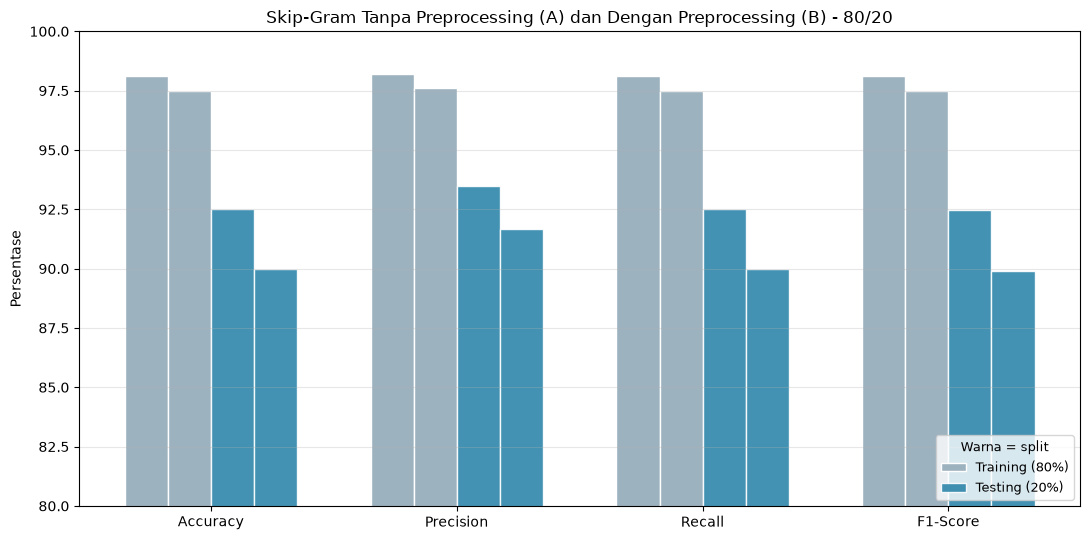

In [12]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(METRIK))
lebar = 0.35
warna = {"Training (80%)": "#9DB2BF", "Testing (20%)": "#2E86AB"}

for i, (data, sumber) in enumerate([("Training (80%)", latih), ("Testing (20%)", uji)]):
    for j, proses in enumerate(sumber.index):
        nilai = [sumber.loc[proses, m] * 100 for m in METRIK]
        geser = (i - 0.5) * lebar + (j - 0.5) * lebar / 2
        ax.bar(x + geser, nilai, lebar / 2, label=data, color=warna[data],
               edgecolor="white", alpha=0.9 + 0.1 * (i == 0))

ax.set_xticks(x)
ax.set_xticklabels(METRIK)
ax.set_ylabel("Persentase")
ax.set_ylim(80, 100)
ax.set_title("Skip-Gram Tanpa Preprocessing (A) dan Dengan Preprocessing (B) - 80/20")
ax.grid(axis="y", alpha=0.3)

handles, nama_legenda = ax.get_legend_handles_labels()
unik = dict(zip(nama_legenda, handles))
urut = ["Training (80%)", "Testing (20%)"]
ax.legend([unik[k] for k in urut if k in unik], urut, loc="lower right",
          title="Warna = split", fontsize=9, title_fontsize=9)
plt.tight_layout()
plt.show()

## Kesimpulan Skip-Gram

Tiga hal yang bisa disimpulkan dari bagian skip-gram di atas.

1. **Split 80/20 memberi ukuran yang jujur.** Pada jalur A, akurasi training
   98,1 persen, sedangkan akurasi testing 92,5 persen. Selisih 5,6 poin itu
   adalah bagian yang tidak bisa dibawa ke berita baru. Tanpa split, kedua
   angka itu akan sama-sama tinggi dan tidak bisa dipisahkan.
2. **Preprocessing memperkecil korpus, dan itu efeknya nyata.** Jumlah token
   turun 27 persen, dari 47.834 menjadi 34.878, dan vocabulary model menyusut
   dari 6.730 menjadi 6.516 kata. Kata umum dan bentuk tidak baku yang dibuang
   memang tidak membawa informasi pembeda antara finance dan olahraga.
3. **Untuk klasifikasi berita ini, preprocessing tidak otomatis membantu.**
   Jalur B justru 2,5 poin lebih rendah pada data testing. Selisih segitu
   masuk kategori kebetulan, sebab hanya 40 berita uji. Jadi kesimpulan yang
   aman: preprocessing berhasil membersihkan teks, tetapi pada korpus kecil
   seperti ini cleaning tidak otomatis menaikkan performa klasifikasi.


In [13]:
def persen(nilai):
    """Ubah rasio jadi persen, bulatin 1 desimal, dan avoid -0.0."""
    n = round(nilai * 100, 1)
    return 0.0 if n == 0 else n


print("HASIL AKHIR")
print("=" * 66)
for proses in uji.index:
    tr = persen(latih.loc[proses, "Accuracy"])
    te = persen(uji.loc[proses, "Accuracy"])
    print(f"\n{proses}")
    print(f"  accuracy training (160 berita) : {tr} %")
    print(f"  accuracy testing  (40 berita)  : {te} %")
    print(f"  selisih training - testing       : {persen(latih.loc[proses, 'Accuracy'] - uji.loc[proses, 'Accuracy']):+.1f} poin")

print()
print("=" * 66)
print("Selisih preprocessing (B - A) pada data testing:")
for m in METRIK:
    a = persen(uji.loc["A - tanpa preprocessing", m])
    b = persen(uji.loc["B - dengan preprocessing", m])
    print(f"  {m:<10} A {a:5.1f} %   B {b:5.1f} %   selisih {persen(uji.loc['B - dengan preprocessing', m] - uji.loc['A - tanpa preprocessing', m]):+.1f} poin")

print()
print("=" * 66)
print("Bentuk data setelah preprocessing (bagian training):")
def ambil(tabel, kolom, split="Training (80%)"):
    return tabel[tabel["Split"] == split][kolom].iat[0]

for kolom in ("Jumlah Token", "Kata Unik", "Vocabulary Model", "Token OOV"):
    a = ambil(tabel_stat_a, kolom)
    b = ambil(tabel_stat_b, kolom)
    print(f"  {kolom:<18} A {a:>6}  ->  B {b:>6}   ({b - a:+d})")

HASIL AKHIR

A - tanpa preprocessing
  accuracy training (160 berita) : 98.1 %
  accuracy testing  (40 berita)  : 92.5 %
  selisih training - testing       : +5.6 poin

B - dengan preprocessing
  accuracy training (160 berita) : 97.5 %
  accuracy testing  (40 berita)  : 90.0 %
  selisih training - testing       : +7.5 poin

Selisih preprocessing (B - A) pada data testing:
  Accuracy   A  92.5 %   B  90.0 %   selisih -2.5 poin
  Precision  A  93.5 %   B  91.7 %   selisih -1.8 poin
  Recall     A  92.5 %   B  90.0 %   selisih -2.5 poin
  F1-Score   A  92.5 %   B  89.9 %   selisih -2.6 poin

Bentuk data setelah preprocessing (bagian training):
  Jumlah Token       A  47834  ->  B  34878   (-12956)
  Kata Unik          A   6730  ->  B   6516   (-214)
  Vocabulary Model   A   6730  ->  B   6516   (-214)
  Token OOV          A      0  ->  B      0   (+0)


## TF-IDF sebagai Teknik Vektorisasi Kedua

Section di atas memakai skip-gram untuk mengubah teks berita menjadi angka. Section
ini melakukan hal yang sama persis, hanya dengan teknik yang berbeda, yaitu TF-IDF.
Tujuannya supaya dua teknik vektorisasi bisa dibandingkan pada klasifikasi yang sama,
dan kelihatan mana yang lebih cocok untuk data berita.

Prinsipnya tetap sama seperti di section skip-gram: **yang dibandingkan hanya teknik
vektorisasinya**. Semua komponen lain bukan disetel ulang, tapi dipakai ulang apa
adanya dari section sebelumnya:

- Data, pembagian 80/20, dan `stratify="tema"` diambil dari `idx_train` dan
  `idx_test` yang sudah ada. Tidak ada split kedua di notebook ini.
- Jalur A dan Jalur B memakai token `TOK["A"]` dan `TOK["B"]` yang juga sudah ada,
  sehingga perbandingan preprocessing di dua teknik benar-benar apples-to-apples.
- Klasifikasi tetap Gaussian Naive Bayes, dan metrik tetap `average="macro"`.

Dua hal memang wajib berubah, dan keduanya memang berbeda sifat. Pertama, TF-IDF
tidak punya tahap pelatihan apa pun, tidak ada epoch dan tidak ada negative sampling
seperti Word2Vec. Kedua, hasilnya bukan vektor 100 dimensi yang penuh, tapi matriks
jarang (*sparse*) dengan ribuan kolom.

In [14]:
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer

PARAM_TFIDF = dict(
    use_idf=True,
    norm="l2",
    smooth_idf=True,
    sublinear_tf=False,
    token_pattern=r"(?u)\b\w\w+\b",
    lowercase=False,
    min_df=1,
)

KATA_TFIDF = ["saham", "rupiah", "investor", "emas",
              "gol", "klub", "pemain", "liga"]

RE_TOKEN_TFIDF = re.compile(PARAM_TFIDF["token_pattern"])

print(f"scikit-learn {sklearn.__version__} | TfidfVectorizer siap")
print("PARAM_TFIDF:", PARAM_TFIDF)
print("Kata yang akan ditunjukkan:", ", ".join(KATA_TFIDF))

scikit-learn 1.9.1 | TfidfVectorizer siap
PARAM_TFIDF: {'use_idf': True, 'norm': 'l2', 'smooth_idf': True, 'sublinear_tf': False, 'token_pattern': '(?u)\\b\\w\\w+\\b', 'lowercase': False, 'min_df': 1}
Kata yang akan ditunjukkan: saham, rupiah, investor, emas, gol, klub, pemain, liga


### Jalur A dan Jalur B Dijalankan Bersamaan

Fungsi `bangun_tfidf` dipanggil dua kali, sekali untuk token Jalur A dan sekali untuk
token Jalur B. Fungsi itu ditulis satu kali lalu dipanggil dua kali, bukan ditulis
ulang dua kali, supaya tidak ada peluang salah ubah salah satu jalurnya saja.

Di dalam fungsi itu urutannya selalu sama: `fit_transform` pada 160 berita training,
lalu `transform` pada 40 berita testing. Setelah itu fungsi ini melaporkan ukuran
matriks, tingkat kejarangan (*sparsity*), dan berapa banyak token testing yang
jatuh di luar vocabulary.

In [15]:
def token_tfidf(token):
    # token final yang benar-benar dilihat TfidfVectorizer, setelah penyaringan
    # token_pattern. Dipakai supaya statistik di tabel sama sekali input TF-IDF,
    # bukan token mentah hasil tokenisasi.
    return [m for t in token for m in RE_TOKEN_TFIDF.findall(" ".join(t))]


def bangun_tfidf(token, nama_proses):
    # 1. fit HANYA pada 160 berita training
    dok_train = [" ".join(token[i]) for i in idx_train]
    dok_test = [" ".join(token[i]) for i in idx_test]

    vec = TfidfVectorizer(**PARAM_TFIDF)
    X_train = vec.fit_transform(dok_train)
    X_test = vec.transform(dok_test)

    # 2. laporan singkat: matriks, kejarangan, dan token testing di luar vocabulary
    jarang_tr = 100 * (1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1]))
    vocab = set(vec.get_feature_names_out())
    token_test = token_tfidf([token[i] for i in idx_test])
    oov = [w for w in token_test if w not in vocab]

    print(f"{nama_proses}")
    print(f"  matriks training {X_train.shape} | matriks testing {X_test.shape}")
    print(f"  vocabulary {len(vocab)} kata | kejarangan training {jarang_tr:.2f}%")
    print(f"  token testing di luar vocabulary {len(oov)} dari {len(token_test)} "
          f"({100 * len(oov) / len(token_test):.2f}%)")
    return vec, X_train, X_test


print("TF-IDF Jalur A - tanpa preprocessing")
vec_a, Xtr_a, Xte_a = bangun_tfidf(TOK["A"], "A - tanpa preprocessing")
print()
print("TF-IDF Jalur B - dengan preprocessing")
vec_b, Xtr_b, Xte_b = bangun_tfidf(TOK["B"], "B - dengan preprocessing")

TF-IDF Jalur A - tanpa preprocessing


A - tanpa preprocessing
  matriks training (160, 6711) | matriks testing (40, 6711)
  vocabulary 6711 kata | kejarangan training 97.47%
  token testing di luar vocabulary 1349 dari 12476 (10.81%)

TF-IDF Jalur B - dengan preprocessing


B - dengan preprocessing
  matriks training (160, 6516) | matriks testing (40, 6516)
  vocabulary 6516 kata | kejarangan training 97.87%
  token testing di luar vocabulary 1314 dari 9206 (14.27%)


### Tabel 5 - Statistik Matriks TF-IDF

Kolom `Dimensi Matriks` adalah jumlah kata di vocabulary. Kolomnya **sama untuk
training dan testing**, dan itu bukan salah ketik: vocabulary-nya memang dibangun
sekali dari training lalu dipakai ulang, jadi testing tidak pernah menambah kata
baru.

Kolom `Kejarangan (%)` menunjukkan berapa persen isi matriks yang bernilai nol.
Angkanya tinggi, sekitar 97 persen, dan itu memang sifat TF-IDF, bukan cacat. Tiap
berita hanya berisi ratusan kata sementara tiap matriks punya ribuan kolom, jadi
mayoritas kolom memang tidak tersentuh berita tersebut. Kolom yang tidak tersentuh
itu bernilai nol, dan itulah yang membuat bobot kata di berita itu nol. Di sinilah
letak perbedaannya dengan skip-gram: vektor skip-gram padat 100 angka per berita,
sementara baris TF-IDF punya ribuan angka tapi hanya ratusan yang tidak nol.

Kolom `% di Luar Vocab` perlu dibaca hati-hati, dan polanya persis sama seperti di
section skip-gram: persentagetya justru **naik** dari Jalur A ke Jalur B. Itu bukan
tanda preprocessing gagal. Setelah stopword dibuang, token yang tersisa lebih banyak
berisi kata yang hanya muncul di berita testing, sehingga kata-kata itu lebih banyak
yang belum pernah dilihat saat fitting.

In [16]:
def statistik_tfidf(token, vec, X_train, X_test, nama_proses):
    vocab = set(vec.get_feature_names_out())
    baris = []
    for keterangan, X, idx in (("Training (80%)", X_train, idx_train),
                               ("Testing (20%)", X_test, idx_test)):
        semua = token_tfidf([token[i] for i in idx])
        di_luar = [w for w in semua if w not in vocab]
        baris.append({
            "Proses": nama_proses,
            "Split": keterangan,
            "Jumlah Berita": len(idx),
            "Jumlah Token": len(semua),
            "Kata Unik": len(set(semua)),
            "Rata-rata Token/Berita": len(semua) / len(idx),
            "Dimensi Matriks": X.shape[1],
            "Nilai Non-Nol": X.nnz,
            "Kejarangan (%)": (1 - X.nnz / (X.shape[0] * X.shape[1])) * 100,
            "Token di Luar Vocab": len(di_luar),
            "% di Luar Vocab": len(di_luar) / len(semua) * 100,
        })
    return pd.DataFrame(baris)


print("Tabel 5 - Statistik Matriks TF-IDF")
tabel_stat_tfidf = pd.concat(
    [
        statistik_tfidf(TOK["A"], vec_a, Xtr_a, Xte_a, "TF-IDF A - tanpa preprocessing"),
        statistik_tfidf(TOK["B"], vec_b, Xtr_b, Xte_b, "TF-IDF B - dengan preprocessing"),
    ],
    ignore_index=True,
)
display(tabel_stat_tfidf.round(2))

Tabel 5 - Statistik Matriks TF-IDF


,Proses,Split,Jumlah Berita,Jumlah Token,Kata Unik,Rata-rata Token/Berita,Dimensi Matriks,Nilai Non-Nol,Kejarangan (%),Token di Luar Vocab,% di Luar Vocab
0,TF-IDF A - tanpa preprocessing,Training (80%),160,47604,6711,297.52,6711,27114,97.47,0,0.00
1,TF-IDF A - tanpa preprocessing,Testing (20%),40,12476,2886,311.90,6711,5977,97.77,1349,10.81
2,TF-IDF B - dengan preprocessing,Training (80%),160,34878,6516,217.99,6516,22179,97.87,0,0.00
3,TF-IDF B - dengan preprocessing,Testing (20%),40,9206,2753,230.15,6516,4772,98.17,1314,14.27


### Tabel 6 - Bobot Kata TF-IDF

Padanan tabel vektor kata di section skip-gram. Bedanya ada pada bentuk angkanya.
Skip-gram menghasilkan vektor 100 dimensi hasil latihan jaringan, sedangkan TF-IDF
menghasilkan satu angka per kata yang dihitung langsung dengan rumus, dan angka itu
bisa dibaca serta diperiksa sendiri.

Kolom `IDF` adalah bobot kelangkaan kata. Nilainya mendekati 1 untuk kata yang muncul
di hampir semua berita, dan makin kecil untuk kata yang hanya muncul di sedikit
berita. Kata yang paling langka justru paling besar nilainya, karena informasi
paling banyak justru ada di kata yang jarang.

Kolom `TF-IDF Tertinggi` adalah bobot kata itu di satu berita training tertentu,
sesuai nomor pada kolom `Berita ID`. Kolom `Jumlah Berita` memberi gambaran seberapa
luas kata itu dipakai, sehingga kelihatan apakah bobot tinggi itu muncul karena kata
nya langka atau karena memang sering dipakai.

A dan B ditampilkan berdampingan supaya langsung kelihatan efek preprocessing pada
bobot yang sama.

In [17]:
def bobot_kata_per_kata(vec, X_train, token):
    nama_kata = vec.get_feature_names_out()
    posisi = {k: i for i, k in enumerate(nama_kata)}
    idf = vec.idf_
    baris = []
    for w in KATA_TFIDF:
        if w not in posisi:
            continue
        kolom = posisi[w]
        bobot = X_train[:, kolom].toarray().ravel()
        imax = int(np.argmax(bobot))
        baris.append({
            "Kata": w,
            "Jumlah Berita": sum(1 for i in idx_train if w in token[i]),
            "IDF": round(float(idf[kolom]), 4),
            "TF-IDF Tertinggi": round(float(bobot[imax]), 4),
            "Rata-rata Bobot": round(float(bobot.mean()), 4),
            "Berita ID": df.iloc[idx_train[imax]]["id"],
        })
    return pd.DataFrame(baris).set_index("Kata")


tabel_bobot = pd.concat(
    [
        bobot_kata_per_kata(vec_a, Xtr_a, TOK["A"]).add_prefix("A - "),
        bobot_kata_per_kata(vec_b, Xtr_b, TOK["B"]).add_prefix("B - "),
    ],
    axis=1,
)

print("Tabel 6 - Bobot Kata TF-IDF pada 160 berita training")
display(tabel_bobot.round(4))

Tabel 6 - Bobot Kata TF-IDF pada 160 berita training


,A - Jumlah Berita,A - IDF,A - TF-IDF Tertinggi,A - Rata-rata Bobot,A - Berita ID,B - Jumlah Berita,B - IDF,B - TF-IDF Tertinggi,B - Rata-rata Bobot,B - Berita ID
Kata,,,,,,,,,,
saham,8,3.8842,0.5379,0.0123,96,8,3.8842,0.5466,0.0128,96
rupiah,7,4.0020,0.1156,0.0025,26,7,4.0020,0.1211,0.0027,26
investor,8,3.8842,0.1522,0.0034,66,8,3.8842,0.1629,0.0036,66
emas,8,3.8842,0.5344,0.0096,1,8,3.8842,0.5379,0.0102,1
gol,18,3.1370,0.3433,0.0106,139,18,3.1370,0.3655,0.0111,139
klub,20,3.0369,0.2255,0.0087,115,20,3.0369,0.2313,0.0091,115
pemain,21,2.9904,0.3131,0.0120,183,21,2.9904,0.3348,0.0127,183
liga,26,2.7856,0.3353,0.0162,139,26,2.7856,0.3570,0.0171,139


### Tabel 7 - Kata dengan Bobot Rata-rata Tertinggi per Tema

Section skip-gram menampilkan vektor kata, tapi tidak pernah menunjukkan kata mana
yang paling menentukan. TF-IDF bisa langsung menunjukkan itu, karena bobot tiap kata
dapat dibaca sebagai ringkasan langsung tanpa perlu menebak.

Cara caranya sederhana: bobot rata-rata tiap kata dihitung khusus untuk berita
finance saja, lalu diurutkan. Diulang untuk berita olahraga. Kata dengan bobot
rata-rata tertinggi di tiap kelompok dianggap kata yang paling menandai tema itu.

Tabel ini sekaligus memperlihatkan efek preprocessing dengan paling jelas. Di Jalur
A, sepuluh besar kata teratas di kedua tema masih didominasi kata umum seperti
`yang`, `di`, dan `dan`. Kata-kata itu muncul di semua berita, jadi tidak membedakan
finance dari olahraga, dan IDF-nya memang tinggi karena jarang. Di Jalur B semuanya
hilang, digantikan kata seperti `rekening`, `saham`, `harga`, `liga`, dan `tim`.

In [18]:
def top_kata_tema(vec, X_train, n=10):
    nama_kata = vec.get_feature_names_out()
    hasil = {}
    for tema in sorted(set(label)):
        baris = np.where(label[idx_train] == tema)[0]
        rerata = np.asarray(X_train[baris].mean(axis=0)).ravel()
        urutan = np.argsort(rerata)[::-1][:n]
        hasil[f"{tema}"] = [f"{nama_kata[j]} ({rerata[j]:.3f})" for j in urutan]
    return hasil


top_a = top_kata_tema(vec_a, Xtr_a)
top_b = top_kata_tema(vec_b, Xtr_b)

print("Tabel 7 - 10 Kata dengan Bobot Rata-rata Tertinggi per Tema")
display(pd.DataFrame({
    "Peringkat": range(1, 11),
    "A - finance": top_a["finance"],
    "A - olahraga": top_a["olahraga"],
    "B - finance": top_b["finance"],
    "B - olahraga": top_b["olahraga"],
}))

Tabel 7 - 10 Kata dengan Bobot Rata-rata Tertinggi per Tema


,Peringkat,A - finance,A - olahraga,B - finance,B - olahraga
0,1,yang (0.065),di (0.081),purbaya (0.049),liga (0.034)
1,2,dan (0.054),yang (0.061),rp (0.043),tim (0.031)
2,3,di (0.049),dan (0.058),rekening (0.032),asian (0.029)
3,4,purbaya (0.046),saya (0.039),harga (0.030),musim (0.028)
4,5,rp (0.041),ini (0.038),pemerintah (0.029),inter (0.027)
5,6,ini (0.041),dengan (0.036),bank (0.028),pertandingan (0.025)
6,7,tersebut (0.037),kami (0.035),saham (0.026),olahraga (0.025)
7,8,untuk (0.035),dari (0.035),pajak (0.024),pemain (0.025)
8,9,dari (0.033),liga (0.032),triliun (0.024),indonesia (0.025)
9,10,akan (0.031),untuk (0.032),indonesia (0.024),laga (0.025)


## Klasifikasi TF-IDF dengan Gaussian Naive Bayes

Klasifikasi di section skip-gram memakai Gaussian Naive Bayes dengan alasan bahwa
vektor skip-gram bisa bernilai negatif, sedangkan Multinomial hanya menerima nilai
tidak negatif. Untuk TF-IDF alasan itu tidak berlaku: semua bobot hasil TF-IDF selalu
nol atau positif, jadi Multinomial Naive Bayes secara teknis bisa dipakai, dan
memang lebih lazim untuk TF-IDF.

GaussianNB tetap dipakai di sini, dan itu pilihan sadar. Kalau algoritma klasifikasi
ikut berubah antara dua section, maka selisih hasil antara skip-gram dan TF-IDF tidak
lagi bisa dikaitkan ke teknik vektorisasi saja, tapi bercampur dengan perubahan
algoritma. Mengunci GaussianNB membuat perbandingan itu jauh lebih bersih:
satunya-s-satunya yang berganti adalah cara teks diubah menjadi angka.

Perlu dicatat juga bahwa perbandingan ini tetap bukan perbandingan yang sepenuhnya
adil. Dimensi kedua teknik berbeda jauh. Skip-Gram menghasilkan 100 dimensi yang
penuh, sedangkan TF-IDF menghasilkan sekitar tujuh ribu dimensi yang jarang. Jumlah
informasi yang dibawa berbeda, jadi angka akurasi di bawah sebaiknya dibaca sebagai
arah kecenderungan, bukan sebagai peringkat akhir.

In [19]:
def klasifikasi_tfidf(X_train, X_test, nama_proses):
    # GaussianNB dikunci sama dengan section skip-gram, supaya selisih antar teknik
    # vektorisasi hanya berasal dari cara teks diubah menjadi angka
    clf = GaussianNB().fit(X_train.toarray(), label[idx_train])
    baris = []
    for keterangan, X, idx in (("Training (80%)", X_train, idx_train),
                               ("Testing (20%)", X_test, idx_test)):
        pred = clf.predict(X.toarray())
        baris.append({
            "Proses": nama_proses,
            "Data": keterangan,
            "Jumlah Berita": len(idx),
            "Accuracy": accuracy_score(label[idx], pred),
            "Precision": precision_score(label[idx], pred, average="macro", zero_division=0),
            "Recall": recall_score(label[idx], pred, average="macro", zero_division=0),
            "F1-Score": f1_score(label[idx], pred, average="macro", zero_division=0),
        })
    return pd.DataFrame(baris)


print("Tabel 8 - Metrik Klasifikasi TF-IDF Train vs Test")
tabel_tfidf = pd.concat(
    [
        klasifikasi_tfidf(Xtr_a, Xte_a, "TF-IDF A - tanpa preprocessing"),
        klasifikasi_tfidf(Xtr_b, Xte_b, "TF-IDF B - dengan preprocessing"),
    ],
    ignore_index=True,
)
display(tabel_tfidf.round(4))

Tabel 8 - Metrik Klasifikasi TF-IDF Train vs Test


,Proses,Data,Jumlah Berita,Accuracy,Precision,Recall,F1-Score
0,TF-IDF A - tanpa preprocessing,Training (80%),160,1.0,1.000,1.0,1.0000
1,TF-IDF A - tanpa preprocessing,Testing (20%),40,0.9,0.904,0.9,0.8997
2,TF-IDF B - dengan preprocessing,Training (80%),160,1.0,1.000,1.0,1.0000
3,TF-IDF B - dengan preprocessing,Testing (20%),40,0.9,0.904,0.9,0.8997


### Tabel 9 - Ringkasan Hasil TF-IDF pada Data Testing

Strukturnya sama persis dengan Tabel 4 di section skip-gram: metrik pada data testing
dengan selisih terhadap jalur A, ditambah besar selisih antara training dan testing
sebagai indikasi apakah model menghafal data.

In [20]:
uji_t = tabel_tfidf[tabel_tfidf["Data"] == "Testing (20%)"].set_index("Proses")
latih_t = tabel_tfidf[tabel_tfidf["Data"] == "Training (80%)"].set_index("Proses")

baris = []
for proses in uji_t.index:
    baris.append({
        "Proses": proses,
        **{m: uji_t.loc[proses, m] for m in METRIK},
        "Selisih Training - Testing": latih_t.loc[proses, "Accuracy"] - uji_t.loc[proses, "Accuracy"],
    })
tabel_ringkas_tfidf = pd.DataFrame(baris)

selisih_t = {
    m: uji_t.loc["TF-IDF B - dengan preprocessing", m] - uji_t.loc["TF-IDF A - tanpa preprocessing", m]
    for m in METRIK
}
tabel_ringkas_tfidf.loc["Selisih B - A (testing)"] = ["-"] + [selisih_t[m] for m in METRIK] + ["-"]

print("Tabel 9 - Ringkasan Hasil TF-IDF pada Data Testing")
display(tabel_ringkas_tfidf.round(4))

Tabel 9 - Ringkasan Hasil TF-IDF pada Data Testing


,Proses,Accuracy,Precision,Recall,F1-Score,Selisih Training - Testing
0,TF-IDF A - tanpa preprocessing,0.9,0.904,0.9,0.8997,0.1
1,TF-IDF B - dengan preprocessing,0.9,0.904,0.9,0.8997,0.1
Selisih B - A (testing),-,0.0,0.000,0.0,0.0000,-


### Diagram Batang TF-IDF

Bentuknya sama persis dengan diagram batang di section skip-gram, supaya kedua teknik
bisa dibandingkan dengan cara baca yang sama. Warna abu-abu untuk data training dan
warna biru untuk data testing.

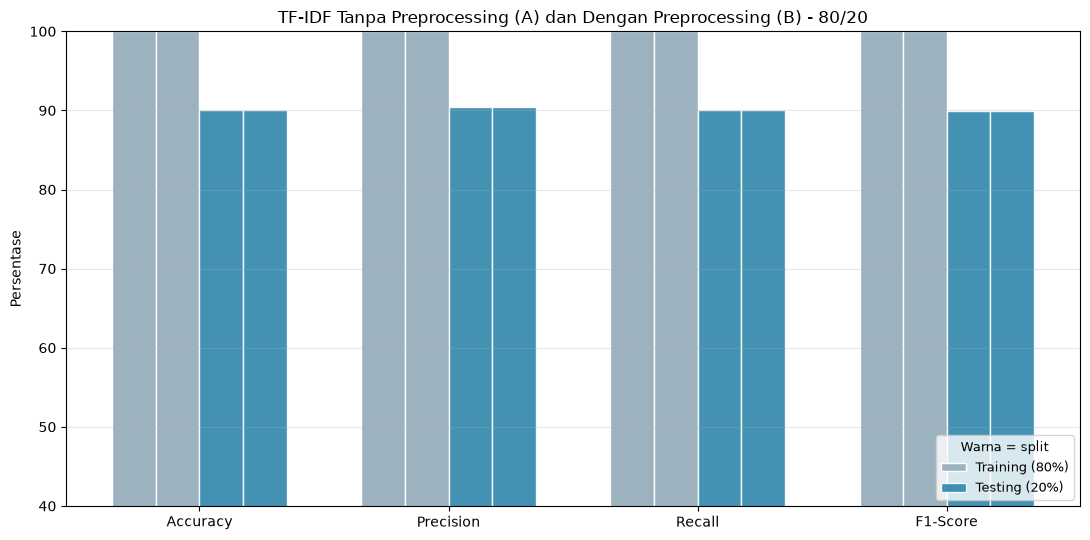

In [21]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(METRIK))
lebar = 0.35
warna = {"Training (80%)": "#9DB2BF", "Testing (20%)": "#2E86AB"}

for i, (data, sumber) in enumerate([("Training (80%)", latih_t), ("Testing (20%)", uji_t)]):
    for j, proses in enumerate(sumber.index):
        nilai = [sumber.loc[proses, m] * 100 for m in METRIK]
        geser = (i - 0.5) * lebar + (j - 0.5) * lebar / 2
        ax.bar(x + geser, nilai, lebar / 2, label=data, color=warna[data],
               edgecolor="white", alpha=0.9 + 0.1 * (i == 0))

ax.set_xticks(x)
ax.set_xticklabels(METRIK)
ax.set_ylabel("Persentase")
ax.set_ylim(40, 100)
ax.set_title("TF-IDF Tanpa Preprocessing (A) dan Dengan Preprocessing (B) - 80/20")
ax.grid(axis="y", alpha=0.3)

# label batang memakai nama split, bukan nama proses, supaya kunci lookup legenda
# benar-benar ditemukan dan legendarinya tidak kosong
handles, nama_legenda = ax.get_legend_handles_labels()
unik = dict(zip(nama_legenda, handles))
urut = ["Training (80%)", "Testing (20%)"]
ax.legend([unik[k] for k in urut if k in unik], urut, loc="lower right",
          title="Warna = split", fontsize=9, title_fontsize=9)
plt.tight_layout()
plt.show()

### Skip-Gram dan TF-IDF Dipandingkan Langsung

Bagian ini menyatukan hasil kedua teknik pada data testing yang sama, supaya
selisihnya kelihatan dalam satu tabel. Kolom tambahan di bawahnya membandingkan
bentuk vektor yang dipakai masing-masing teknik, karena di situlah letak perbedaan
paling besarnya: dense seratus dimensi melawan sparse ribuan dimensi.

In [22]:
def baris_banding(vektorisasi, nama, sumber):
    return {
        "Vektorisasi": vektorisasi,
        "Jalur": nama,
        **{m: sumber.loc[nama, m] for m in METRIK},
    }


tabel_banding = pd.DataFrame([
    baris_banding("Skip-Gram", "A - tanpa preprocessing", uji),
    baris_banding("Skip-Gram", "B - dengan preprocessing", uji),
    baris_banding("TF-IDF", "TF-IDF A - tanpa preprocessing", uji_t),
    baris_banding("TF-IDF", "TF-IDF B - dengan preprocessing", uji_t),
])

print("Perbandingan Skip-Gram vs TF-IDF pada data testing")
display(tabel_banding.round(4))

print()
print("Bentuk vektor yang dipakai tiap teknik:")
print(f"  Skip-Gram    : {model_a.wv.vector_size} dimensi, vektor PENUH "
      f"(setiap berita punya {model_a.wv.vector_size} angka, tidak ada yang nol)")
print(f"  TF-IDF A     : {Xtr_a.shape[1]} dimensi, vektor JARANG "
      f"({100 * (1 - Xtr_a.nnz / (Xtr_a.shape[0] * Xtr_a.shape[1])):.2f}% isinya nol)")
print(f"  TF-IDF B     : {Xtr_b.shape[1]} dimensi, vektor JARANG "
      f"({100 * (1 - Xtr_b.nnz / (Xtr_b.shape[0] * Xtr_b.shape[1])):.2f}% isinya nol)")

print()
print("Bentuk data setelah preprocessing (bagian training):")
for kolom in ("Jumlah Token", "Kata Unik", "Token di Luar Vocab"):
    a = ambil(tabel_stat_tfidf[tabel_stat_tfidf["Proses"].str.startswith("TF-IDF A")],
              kolom)
    b = ambil(tabel_stat_tfidf[tabel_stat_tfidf["Proses"].str.startswith("TF-IDF B")],
              kolom)
    print(f"  {kolom:<22} A {a:>6}  ->  B {b:>6}   ({b - a:+d})")

Perbandingan Skip-Gram vs TF-IDF pada data testing


,Vektorisasi,Jalur,Accuracy,Precision,Recall,F1-Score
0,Skip-Gram,A - tanpa preprocessing,0.925,0.9348,0.925,0.9246
1,Skip-Gram,B - dengan preprocessing,0.900,0.9167,0.900,0.8990
2,TF-IDF,TF-IDF A - tanpa preprocessing,0.900,0.9040,0.900,0.8997
3,TF-IDF,TF-IDF B - dengan preprocessing,0.900,0.9040,0.900,0.8997



Bentuk vektor yang dipakai tiap teknik:
  Skip-Gram    : 100 dimensi, vektor PENUH (setiap berita punya 100 angka, tidak ada yang nol)
  TF-IDF A     : 6711 dimensi, vektor JARANG (97.47% isinya nol)
  TF-IDF B     : 6516 dimensi, vektor JARANG (97.87% isinya nol)

Bentuk data setelah preprocessing (bagian training):
  Jumlah Token           A  47604  ->  B  34878   (-12726)
  Kata Unik              A   6711  ->  B   6516   (-195)
  Token di Luar Vocab    A      0  ->  B      0   (+0)


## Kesimpulan TF-IDF

Lima hal yang bisa disimpulkan dari bagian TF-IDF di atas.

1. **TF-IDF tidak perlu dilatih, tapi tetap harus di-fit di training saja.** Yang
   "dipelajari"-nya hanya vocabulary dan tabel IDF. Kalau `fit` dilakukan pada 200
   berita sekaligus, tabel IDF ikut bocor dari 40 berita testing dan akurasinya jadi
   terlalu optimis. Pemisahan `fit_transform` dan `transform` di atas bukan formalitas,
   itu yang mencegah kebocoran tersebut.

2. **Matriksnya sangat jarang, sekitar 97 persen isinya nol.** Dimensinya 6.711 kolom
   untuk Jalur A dan 6.516 kolom untuk Jalur B, padahal tiap berita di training hanya
   mengisi sekitar 140 sampai 170 kolom. Ini perbedaan paling mencolok dari skip-gram,
   yang vektor beritanya 100 angka penuh tanpa kejarangan.

3. **Preprocessing tidak mengubah hasil klasifikasi sama sekali.** Empat metrik di
   Jalur A dan Jalur B identik sampai tiga desimal, jadi selisihnya nol poin.
   Bandingkan dengan skip-gram, yang bergerak 2,5 poin setelah preprocessing. Angka nol
   ini tidak berarti preprocessing tidak berguna, karena Tabel 7 menunjukkan kata yang
   paling menandai tiap tema di Jalur B jauh lebih bermakna daripada di Jalur A. Yang
   berubah adalah keterbacaan, bukan akurasi.

4. **TF-IDF lebih mudah menghafal data training.** Akurasi training 100 persen pada
   kedua jalur, sedangkan akurasi testing hanya 90 persen, jadi selisihnya 10 poin.
   Pada skip-gram selisihnya hanya 5,6 sampai 7,5 poin. Matriks yang jauh lebih besar
   ternyata lebih mudah menghafal 160 berita training.

5. **TF-IDF memberi sesuatu yang tidak diberikan skip-gram, yaitu keterbacaan.** Bobot
   tiap kata bisa diperiksa langsung sebagai hasil perkalian TF dengan IDF, dan Tabel
   7 bisa langsung menunjukkan kata mana yang paling menandai tiap tema. Vektor
   skip-gram tidak bisa dibaca seperti itu, karena 100 dimensinya hasil latihan
   jaringan, bukan hasil rumus.

In [23]:
print("RINGKASAN AKHIR - TF-IDF")
print("=" * 70)
for proses in uji_t.index:
    print()
    print(proses)
    print(f"  accuracy training (160 berita) : {persen(latih_t.loc[proses, 'Accuracy'])} %")
    print(f"  accuracy testing  (40 berita)  : {persen(uji_t.loc[proses, 'Accuracy'])} %")
    print(f"  selisih training - testing       : "
          f"{persen(latih_t.loc[proses, 'Accuracy'] - uji_t.loc[proses, 'Accuracy']):+.1f} poin")

print()
print("=" * 70)
print("Selisih preprocessing (B - A) pada data testing:")
for m in METRIK:
    a = persen(uji_t.loc["TF-IDF A - tanpa preprocessing", m])
    b = persen(uji_t.loc["TF-IDF B - dengan preprocessing", m])
    d = persen(selisih_t[m])
    print(f"  {m:<10} A {a:5.1f} %   B {b:5.1f} %   selisih {d:+.1f} poin")

print()
print("=" * 70)
print("Skip-Gram vs TF-IDF pada data testing:")
for teknik, sumber, label_a, label_b in (
    ("Skip-Gram", uji, "A - tanpa preprocessing", "B - dengan preprocessing"),
    ("TF-IDF", uji_t, "TF-IDF A - tanpa preprocessing", "TF-IDF B - dengan preprocessing"),
):
    a = persen(sumber.loc[label_a, "Accuracy"])
    b = persen(sumber.loc[label_b, "Accuracy"])
    print(f"  {teknik:<10} jalur A {a:5.1f} %   jalur B {b:5.1f} %")

RINGKASAN AKHIR - TF-IDF

TF-IDF A - tanpa preprocessing
  accuracy training (160 berita) : 100.0 %
  accuracy testing  (40 berita)  : 90.0 %
  selisih training - testing       : +10.0 poin

TF-IDF B - dengan preprocessing
  accuracy training (160 berita) : 100.0 %
  accuracy testing  (40 berita)  : 90.0 %
  selisih training - testing       : +10.0 poin

Selisih preprocessing (B - A) pada data testing:
  Accuracy   A  90.0 %   B  90.0 %   selisih +0.0 poin
  Precision  A  90.4 %   B  90.4 %   selisih +0.0 poin
  Recall     A  90.0 %   B  90.0 %   selisih +0.0 poin
  F1-Score   A  90.0 %   B  90.0 %   selisih +0.0 poin

Skip-Gram vs TF-IDF pada data testing:
  Skip-Gram  jalur A  92.5 %   jalur B  90.0 %
  TF-IDF     jalur A  90.0 %   jalur B  90.0 %
